In [1]:
import pandas as pd
import seaborn as srn
import statistics as sts

In [2]:
dados = pd.read_csv('Churn.csv', sep=';')
dados.head()

,X0,X1,X2,X3,X4,X4.1,X6,X7,X8,X9,X10,X11
0,1,619,RS,Feminino,42,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,41,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,42,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,39,1,0,2,0,0,9382663.0,0
4,5,850,SC,Feminino,43,2,12551082,1,1,1,790841.0,0


In [3]:
dados.shape

(999, 12)

In [4]:
dados.columns = ['Id','Score','Estado','Genero','Idade','Patrimonio','Saldo','Produtos','TemCartCredito','Ativo','Salario','Saiu']

In [5]:
dados.head()

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
0,1,619,RS,Feminino,42,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,41,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,42,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,39,1,0,2,0,0,9382663.0,0
4,5,850,SC,Feminino,43,2,12551082,1,1,1,790841.0,0


In [6]:
agrupado = dados.groupby(['Estado']).size()
agrupado

Estado
PR    257
RP      1
RS    478
SC    258
SP      4
TD      1
dtype: int64

<Axes: xlabel='Estado'>

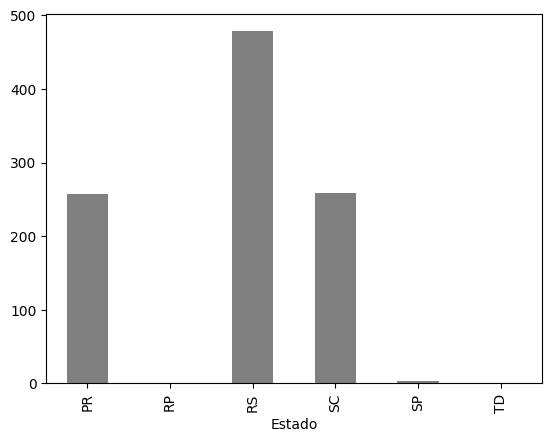

In [7]:
agrupado.plot.bar(color='gray')

In [8]:
agrupado = dados.groupby(['Genero']).size()
agrupado

Genero
F              2
Fem            1
Feminino     461
M              6
Masculino    521
dtype: int64

<Axes: xlabel='Genero'>

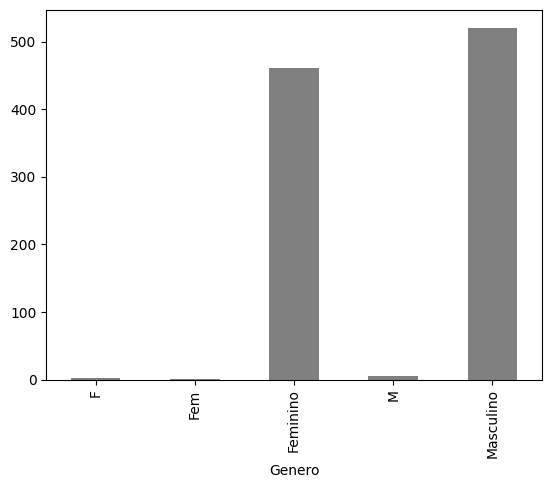

In [9]:
agrupado.plot.bar(color='gray')

In [10]:
dados['Score'].describe()


count    999.000000
mean     648.621622
std       98.264219
min      376.000000
25%      580.000000
50%      653.000000
75%      721.000000
max      850.000000
Name: Score, dtype: float64

Text(0.5, 1.0, 'Score')

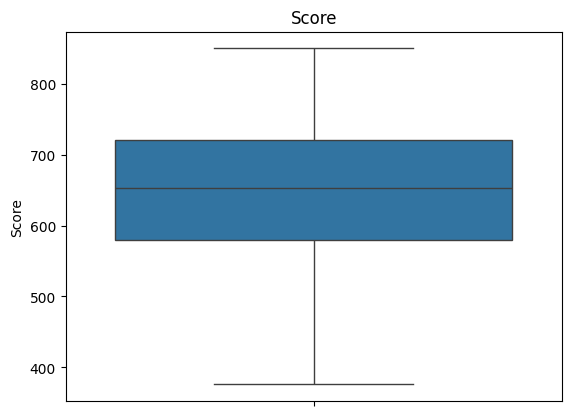

In [11]:
srn.boxplot(dados['Score']).set_title('Score')

AttributeError: 'FacetGrid' object has no attribute 'set_title'

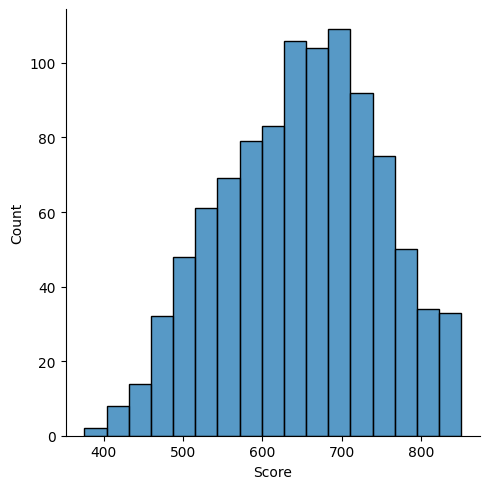

In [12]:
srn.displot(dados['Score']).set_title('Score')

In [53]:
dados['Idade'].describe()

count    998.000000
mean      38.908818
std       10.676642
min        0.000000
25%       32.000000
50%       37.000000
75%       44.000000
max       82.000000
Name: Idade, dtype: float64

Text(0.5, 1.0, 'Idade')

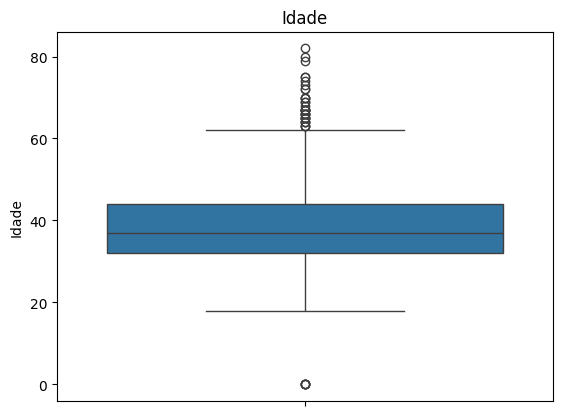

In [54]:
srn.boxplot(dados['Idade']).set_title('Idade')

AttributeError: 'FacetGrid' object has no attribute 'set_title'

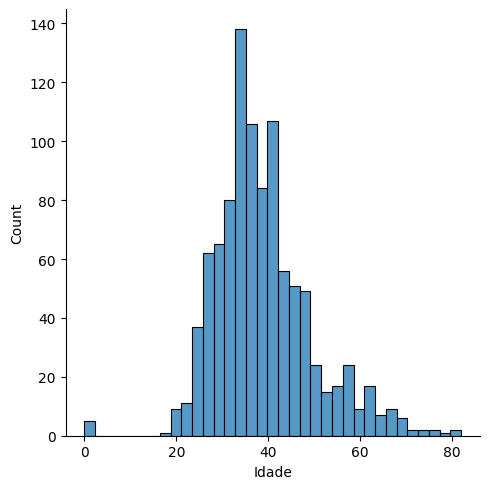

In [55]:
srn.displot(dados['Idade']).set_title('Idade')

In [56]:
dados['Saldo'].describe()

count    9.980000e+02
mean     7.162423e+06
std      6.314508e+06
min      0.000000e+00
25%      0.000000e+00
50%      8.926348e+06
75%      1.258767e+07
max      2.117743e+07
Name: Saldo, dtype: float64

Text(0.5, 1.0, 'Saldo')

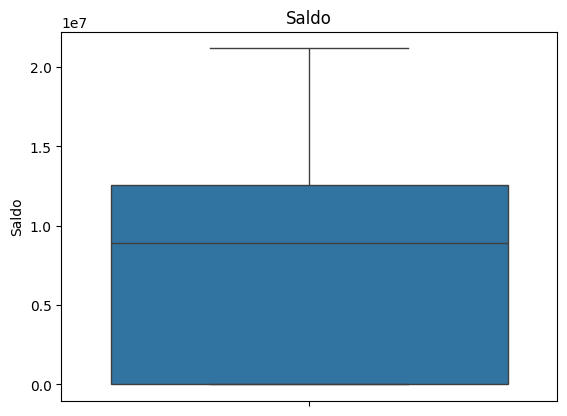

In [57]:
srn.boxplot(dados['Saldo']).set_title('Saldo')

AttributeError: 'FacetGrid' object has no attribute 'set_title'

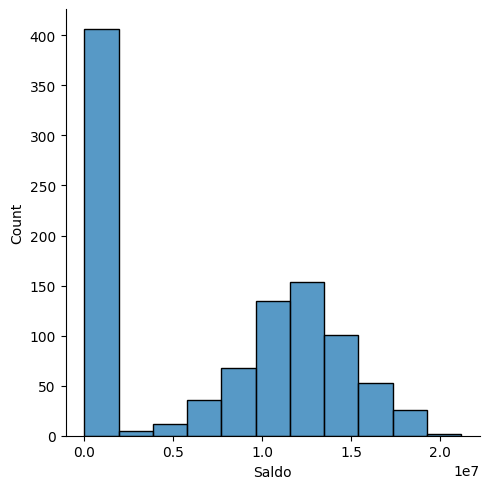

In [58]:
srn.displot(dados['Saldo']).set_title('Saldo')

In [13]:
dados['Salario'].describe()


count    9.920000e+02
mean     3.528762e+07
std      5.305800e+08
min      9.677000e+03
25%      3.029011e+06
50%      8.703250e+06
75%      1.405213e+07
max      1.193469e+10
Name: Salario, dtype: float64

Text(0.5, 1.0, 'Salario')

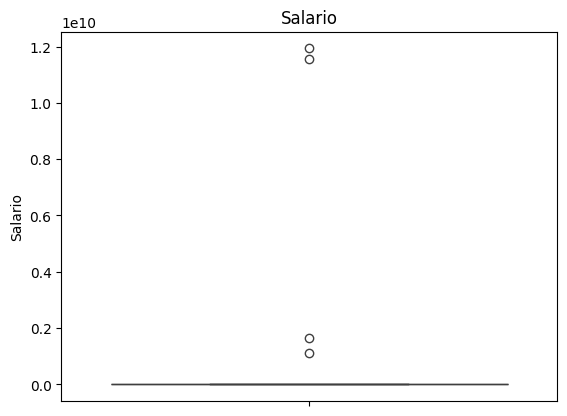

In [14]:
srn.boxplot(dados['Salario']).set_title('Salario')

AttributeError: 'FacetGrid' object has no attribute 'set_title'

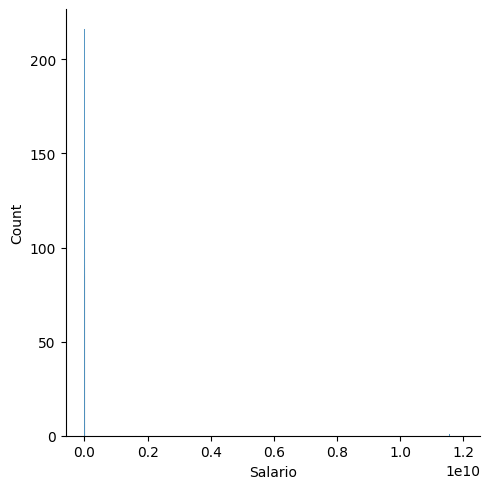

In [15]:
srn.displot(dados['Salario']).set_title('Salario')

In [16]:
dados.isnull().sum()

Id                0
Score             0
Estado            0
Genero            8
Idade             0
Patrimonio        0
Saldo             0
Produtos          0
TemCartCredito    0
Ativo             0
Salario           7
Saiu              0
dtype: int64

In [17]:
mediana = sts.median(dados['Salario'])
mediana

70518.0

In [59]:
dados.fillna({'Salario': mediana},inplace=True)

In [19]:
dados['Salario'].isnull().sum()

np.int64(0)

In [20]:
dados['Genero'].isnull().sum()

np.int64(8)

In [22]:
agrupado = dados.groupby(['Genero']).size()
agrupado

Genero
F              2
Fem            1
Feminino     461
M              6
Masculino    521
dtype: int64

In [23]:
dados['Genero'].isnull().sum()

np.int64(8)

In [24]:
dados.fillna({'Genero': 'Masculino'},inplace=True)

In [25]:
dados['Genero'].isnull().sum()

np.int64(0)

In [26]:
dados.loc[dados['Genero'] == 'M', 'Genero'] = 'Masculino'
dados.loc[dados['Genero'].isin(['Fem','F']),'Genero'] = 'Feminino'

In [27]:
agrupado = dados.groupby(['Genero']).size()
agrupado

Genero
Feminino     464
Masculino    535
dtype: int64

In [29]:
dados['Idade'].describe()

count    999.000000
mean      38.902903
std       11.401912
min      -20.000000
25%       32.000000
50%       37.000000
75%       44.000000
max      140.000000
Name: Idade, dtype: float64

In [30]:
dados.loc[(dados['Idade'] < 0) | (dados['Idade'] > 120)]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
867,869,636,RS,Feminino,-10,1,17083346,1,1,0,11051028.0,1
984,986,773,RS,Masculino,-20,1,12453278,2,0,1,1172357.0,0
990,992,655,RS,Masculino,140,5,93147,2,1,0,6621413.0,0


In [31]:
mediana = sts.median(dados['Idade'])
mediana

37

In [32]:
dados.loc[(dados['Idade'] < 0) | (dados['Idade'] > 120), 'Idade'] = mediana

In [33]:
dados.loc[(dados['Idade'] < 0) | (dados['Idade'] > 120)]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu


In [37]:
dados[dados.duplicated(['Id'],keep=False)]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
80,81,665,RS,Feminino,34,1,9664554,2,0,0,17141366.0,0
81,81,665,RS,Feminino,34,1,9664554,2,0,0,17141366.0,0


In [39]:
#excluimso pelo ID
dados.drop_duplicates(subset="Id", keep='first',inplace=True)
#buscamos duplicados 
dados[dados.duplicated(['Id'],keep=False)]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu


In [41]:
agrupado = dados.groupby(['Estado']).size()
agrupado

Estado
PR    257
RP      1
RS    477
SC    258
SP      4
TD      1
dtype: int64

In [42]:
#atribuomos RS (moda)
dados.loc[dados['Estado'].isin( ['RP','SP','TD']), 'Estado'] = "RS"
agrupado = dados.groupby(['Estado']).size()

In [43]:
agrupado

Estado
PR    257
RS    483
SC    258
dtype: int64

In [45]:
#outliers em salário, vamos considerar 2 desvios padrão
desv = sts.stdev(dados['Salario'])
desv

528988918.4679201

In [46]:
#definir padrão como maior que 2 desvios padrão
#checamos se algum atende critério
dados.loc[dados['Salario'] >=  2 * desv ] 


,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
7,8,376,PR,Feminino,29,4,11504674,4,1,0,1.193469e+10,1
116,118,668,PR,Feminino,37,6,1678644,1,1,0,1.156383e+10,0
170,172,484,RS,Feminino,29,4,13011439,1,1,0,1.640179e+09,0
230,232,673,RS,Masculino,72,1,0,2,0,1,1.119812e+09,0


In [48]:
#vamos atualiar salarios para mediana, calculamos
mediana = sts.median(dados['Salario'])
mediana

8637195.5

In [49]:
#atribumos
dados.loc[dados['Salario'] >=  2 * desv, 'Salario'] = mediana
#checamos se algum atende critério
dados.loc[dados['Salario'] >=  2 * desv ] 

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu


In [50]:
dados.head()

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
0,1,619,RS,Feminino,42,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,41,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,42,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,39,1,0,2,0,0,9382663.0,0
4,5,850,SC,Feminino,43,2,12551082,1,1,1,790841.0,0


In [52]:
dados.shape

(998, 12)